# Lab 01 - Classifying Spam Emails

Notebook này đi theo flow phân tích rõ ràng từ data đến model:

1. **Raw data thế nào?** Load raw/processed data, EDA trên raw: missing, duplicate, label/source distribution.
2. **Clean và preprocess.** Làm sạch text, tạo feature `clean_text`, kiểm tra missing/duplicate sau preprocess, EDA trên data clean nhưng **chưa balance**.
3. **Balance data.** Downsample để ham/spam cân bằng, EDA sau balance.
4. **Bổ sung ham data v2.** Load thêm ham từ `data_v2`, EDA nguồn mới trước khi đưa vào train.
5. **Chia dataset.** Cố định một test set từ data v1 clean/unbalanced; data v2 chỉ được thêm vào train để tránh leakage.
6. **Train 9 phiên bản.** 3 training datasets (`Balanced`, `Unbalanced`, `V2 merged`) x 3 model (`Naive Bayes`, `Logistic Regression`, `Linear SVM`), vẽ 9 confusion matrices.
7. **Tính metric chính.** In `TP`, `FP`, `TN`, `FN`, `precision`, `recall/TPR`, `FPR`, `FNR`, `TNR`, `accuracy`, và assert lại công thức.
8. **Check lại với sklearn.** So sánh bản from-scratch với sklearn trên sample để kiểm tra logic.
9. **Threshold tuning.** Chọn threshold trên validation theo mục tiêu `TPR ~ 99%` và `FPR ~ 1%`, sau đó chỉ báo cáo cuối trên test.
10. **Failure analysis.** Phân tích vì sao chưa đạt 99/1 và issue nằm ở data/feature/model nào.


## Step 0 — Import Libraries And Setup


In [ ]:
from pathlib import Path
import importlib
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
NOTEBOOKS_DIR = PROJECT_ROOT / "notebooks"

for module_path in [NOTEBOOKS_DIR, PROJECT_ROOT]:
    module_path = str(module_path)
    if module_path in sys.path:
        sys.path.remove(module_path)
    sys.path.insert(0, module_path)

import crawl
import preprocess
import model_from_scratch
import eda
import utils

crawl = importlib.reload(crawl)
preprocess = importlib.reload(preprocess)
model_from_scratch = importlib.reload(model_from_scratch)
eda = importlib.reload(eda)
utils = importlib.reload(utils)
model_checker = model_from_scratch.SklearnModelChecker()

paths = crawl.project_paths(PROJECT_ROOT)
print(f"crawl module: {crawl.__file__}")
print(f"preprocess module: {preprocess.__file__}")
print(f"model module: {model_from_scratch.__file__}")
print(f"eda module: {eda.__file__}")
print(f"utils module: {utils.__file__}")
PROJECT_ROOT

crawl module: c:\Users\USER\Downloads\lab01-machine-learning\notebooks\crawl.py
preprocess module: c:\Users\USER\Downloads\lab01-machine-learning\notebooks\preprocess.py
model module: c:\Users\USER\Downloads\lab01-machine-learning\notebooks\model_from_scratch.py
eda module: c:\Users\USER\Downloads\lab01-machine-learning\notebooks\eda.py
utils module: c:\Users\USER\Downloads\lab01-machine-learning\notebooks\utils.py


WindowsPath('c:/Users/USER/Downloads/lab01-machine-learning')

## Step 1 — Raw Data Overview And Raw EDA

Load dữ liệu raw và file processed hiện có để đối chiếu. Step này trả lời: raw data có bao nhiêu dòng, phân phối label/source thế nào, có missing/duplicate không.


In [ ]:
data, raw_data, paths = crawl.load_datasets(PROJECT_ROOT)
processed_data = data.copy().reset_index(drop=True)
overview = crawl.dataset_overview(processed_data, raw_data)

print(f"Processed rows: {overview['processed_rows']:,}")
print(f"Raw rows: {overview['raw_rows']:,}" if overview["raw_rows"] else "Raw dataset not found")
display(processed_data.head(3))

Processed rows: 9,940
Raw rows: 17,967


,email_id,source,source_family,source_url,local_path,extracted_from,extracted_path,archive_path,label,sender,recipient,subject,body,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,e867904a69f471a38e5c62af5780658acfa5cfbfc16ebc...,aueb_enron2_spam_ham,aueb_enron2_spam_ham,https://www2.aueb.gr/users/ion/data/enron-spam...,data/raw/downloads/aueb_enron2_spam_ham/enron2...,data/raw/downloads/aueb_enron2_spam_ham/enron2...,enron2/spam/0368.2002-05-27.SA_and_HP.spam.txt,enron2/spam/0368.2002-05-27.SA_and_HP.spam.txt,spam,,,lose 20 pounds in 10 days 27540,"lose weight fast , without special diets or ex...",lose 20 pounds in 10 days 27540 lose weight fa...,lose pounds days lose weight fast special diet...,1321,720,99
1,e2ceff977739693c837544b38534fd0166716eb5723775...,aueb_enron5_spam_ham,aueb_enron5_spam_ham,https://www2.aueb.gr/users/ion/data/enron-spam...,data/raw/downloads/aueb_enron5_spam_ham/enron5...,data/raw/downloads/aueb_enron5_spam_ham/enron5...,enron5/spam/0282.2002-05-24.SA_and_HP.spam.txt,enron5/spam/0282.2002-05-24.SA_and_HP.spam.txt,spam,,,clear up your credit online,do you have bad credit and want to have good c...,clear up your credit online do you have bad cr...,clear credit online bad credit want good credi...,198,126,20
2,ab0fbb7447ffd1fd3040fe23e5afa73799060ac1f7f425...,huggingface_kimdongh_spam_dataset,huggingface_kimdongh_spam_dataset,KimDongH/spam_dataset,KimDongH/spam_dataset,huggingface,train/574,train/574,ham,,,,in case you missed the last jeff skilling floo...,in case you missed the last jeff skilling flo...,case missed jeff skilling floor meeting meetin...,161,82,13


In [3]:
if raw_data.empty:
    print("Raw dataset not found; only processed dataset is available.")
    data.info()
else:
    raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17967 entries, 0 to 17966
Data columns (total 14 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   email_id        17967 non-null  object
 1   source          17967 non-null  object
 2   source_family   17967 non-null  object
 3   source_url      17967 non-null  object
 4   local_path      17967 non-null  object
 5   extracted_from  17967 non-null  object
 6   extracted_path  17967 non-null  object
 7   archive_path    17967 non-null  object
 8   label           17967 non-null  object
 9   sender          17967 non-null  object
 10  recipient       17967 non-null  object
 11  subject         17967 non-null  object
 12  body            17967 non-null  object
 13  text            17967 non-null  object
dtypes: object(14)
memory usage: 1.9+ MB


### Step 1.1 — Raw Missing Data Check

Đếm số giá trị missing theo từng cột của raw dataset và visualize để kiểm tra chất lượng dữ liệu trước preprocessing.


,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,email_id,0,0.0,object
3,extracted_from,0,0.0,object
4,extracted_path,0,0.0,object
5,label,0,0.0,object
6,local_path,0,0.0,object
7,recipient,0,0.0,object
8,sender,0,0.0,object
9,source,0,0.0,object


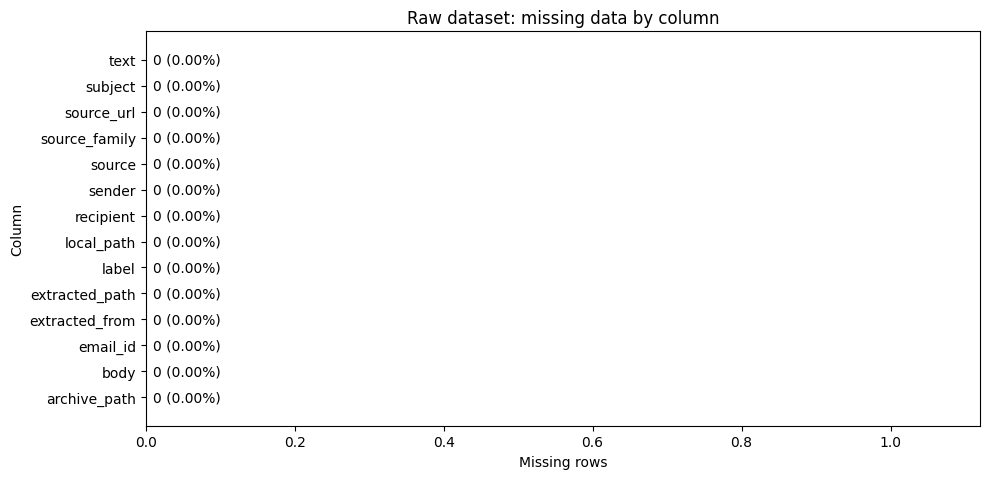

In [4]:
missing_summary = preprocess.missing_data_summary(raw_data)
display(missing_summary)
preprocess.plot_missing_data(raw_data, title="Raw dataset: missing data by column")

### Step 1.2 — Raw Duplicate Rows Check

Đếm số dòng duplicate trong raw dataset và visualize tỉ lệ unique/duplicate trước preprocessing.


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,17967,17967,0,0.0


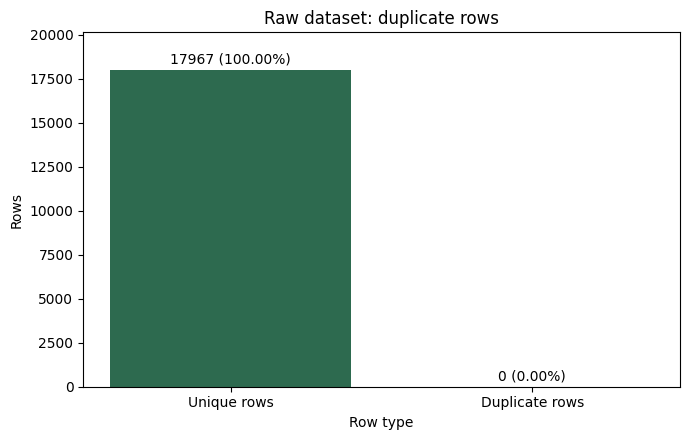

In [5]:
duplicate_summary = preprocess.duplicate_data_summary(raw_data)
display(duplicate_summary)
preprocess.plot_duplicate_data(raw_data, title="Raw dataset: duplicate rows")

### Step 1.3 — Raw Label And Source Distribution


In [6]:
raw_eda_frame = raw_data if not raw_data.empty else data
display(crawl.label_counts(raw_eda_frame))
display(crawl.source_counts(raw_eda_frame, top_n=15))

,label,rows
0,ham,13110
1,spam,4857


,source_family,rows
0,spamassassin,1457
1,kaggle_enron_email_dataset,1000
2,lkml_2024_02_week_3,1000
3,kaggle_email_spam_classification,1000
4,lkml_2022_10_week_1,1000
5,aueb_enron3_spam_ham,999
6,huggingface_enron_spam,996
7,aueb_enron2_spam_ham,995
8,freebsd_hackers_2025,995
9,aueb_enron1_spam_ham,992


In [7]:
display(eda.source_label_table(raw_eda_frame))

label,source_family,ham,spam,total,spam_rate
17,spamassassin,814,643,1457,0.4413
15,lkml_2022_10_week_1,1000,0,1000,0.0000
16,lkml_2024_02_week_3,1000,0,1000,0.0000
14,kaggle_enron_email_dataset,1000,0,1000,0.0000
13,kaggle_email_spam_classification,443,557,1000,0.5570
2,aueb_enron3_spam_ham,499,500,999,0.5005
11,huggingface_enron_spam,496,500,996,0.5020
1,aueb_enron2_spam_ham,495,500,995,0.5025
7,freebsd_hackers_2025,995,0,995,0.0000
0,aueb_enron1_spam_ham,500,492,992,0.4960


## Step 2 — Clean And Preprocess Text

Tạo `clean_text`, lọc các dòng trainable, giữ bản **unbalanced** để nhìn đúng phân phối tự nhiên trước khi balance. Step này cũng check missing/duplicate sau preprocess ở các feature dùng để train.


In [8]:
display(preprocess.processed_sample(data, rows=3, random_state=42))

,label,source_family,subject,body,clean_text
7704,spam,spamassassin,E-Business ...,HOW TO SUBSTANTIALLY INCREASE SALES:\n\nEasily...,e-business c2971 substantially increase sales ...
7883,spam,spamassassin,Complete Online Pharmacy with same day shipping,MERIDIA ® is an FDA-approved oral prescription...,complete online pharmacy day shipping meridia ...
7889,spam,huggingface_enron_spam,,greatly improve your stamina i ' ve been using...,greatly improve stamina ve using product month...


In [9]:
raw_example, clean_example = preprocess.example_cleaning()

print("Raw example:")
print(raw_example)
print("\nCleaned example using notebooks/preprocess.py:")
print(clean_example)

Raw example:
<html><body><h1>WIN MONEY NOW!!!</h1>
Click https://example.com/prize and email winner@example.com to claim $5,000 today.
</body></html>

Cleaned example using notebooks/preprocess.py:
win money claim today


### Step 2.1 — Raw-To-Clean Check On Real Rows

Cell này chứng minh preprocessing chạy trên dữ liệu raw thật, không chỉ trên ví dụ tự tạo.


In [10]:
raw_to_clean = preprocess.raw_to_clean_sample(raw_data, rows=5)
if raw_to_clean.empty:
    print("Raw dataset is not available, so this check is skipped.")
else:
    display(raw_to_clean)

,label,source_family,text,clean_text,raw_char_count,clean_char_count,clean_word_count
0,ham,spamassassin,RE: The Curse of India's Socialism > From: for...,curse india's socialism behalf james rogers cu...,1601,846,114
1,ham,spamassassin,"Re: ARRRGHHH Had GPG working, now it doesnt. H...",arrrghhh gpg working doesnt hi sun sep mdt reg...,987,460,69
2,ham,spamassassin,Re: bad focus/click behaviours On Fri Sep 13 2...,bad focus behaviours fri sep robert elz wrote ...,1527,674,102
3,ham,spamassassin,"Re: ALSA (almost) made easy On Thu, 2002-08-29...",alsa easy thu matthias saou wrote thanks lot r...,1442,699,108
4,ham,spamassassin,creating rpms with subdirs (install command) H...,creating rpms subdirs install command hi i'm b...,803,365,53


### Step 2.2 — EDA After Preprocess, Before Balance

Đây là data đã clean và lọc trainable nhưng **chưa cân bằng**. Đây là baseline phân phối thật của data v1.


In [11]:
full_clean_data, before_balance_data, unbalanced_processed_data = utils.run_preprocess_step(raw_data)

Full cleaned rows: 17,582
Trainable rows after preprocess, before balance: 9,440
Unbalanced label counts


,label,rows
0,ham,4970
1,spam,4470


After preprocess, before balance: missing data in model/features columns


,column,missing_count,missing_percent,dtype
0,clean_char_count,0,0.0,int64
1,clean_text,0,0.0,object
2,clean_word_count,0,0.0,int64
3,label,0,0.0,object
4,raw_char_count,0,0.0,int64
5,source_family,0,0.0,object
6,subject,0,0.0,object
7,text,0,0.0,object


After preprocess, before balance: duplicate clean_text + label


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,"clean_text, label",9440,9440,0,0.0


label,source_family,ham,spam,total,spam_rate
9,spamassassin,770,468,1238,0.3780
2,aueb_enron3_spam_ham,493,494,987,0.5005
8,kaggle_email_spam_classification,437,547,984,0.5559
1,aueb_enron2_spam_ham,490,488,978,0.4990
0,aueb_enron1_spam_ham,491,456,947,0.4815
3,aueb_enron4_spam_ham,492,444,936,0.4744
7,huggingface_kimdongh_spam_dataset,471,446,917,0.4864
5,aueb_enron6_spam_ham,480,423,903,0.4684
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,462,300,762,0.3937


,analysis_char_count,analysis_word_count,subject_chars
count,9440.000000,9440.000000,9440.000000
mean,964.127225,129.466208,25.188559
std,2493.123145,286.546691,25.402622
min,25.000000,5.000000,0.000000
25%,231.000000,33.000000,0.000000
50%,476.000000,67.000000,22.000000
75%,1030.250000,141.000000,39.000000
95%,3067.050000,411.050000,67.000000
max,120772.000000,15414.000000,452.000000


### Step 2.3 — Missing And Duplicate Check After Preprocess

Kiểm tra missing và duplicate sau khi preprocessing — đảm bảo clean_text không còn giá trị rỗng hay dòng trùng lặp trước khi balance.

In [ ]:
eda = importlib.reload(eda)
eda.plot_eda_overview(before_balance_data, title_prefix="After preprocess, before balance")

,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,clean_char_count,0,0.0,int64
3,clean_text,0,0.0,object
4,clean_word_count,0,0.0,int64
5,email_id,0,0.0,object
6,extracted_from,0,0.0,object
7,extracted_path,0,0.0,object
8,label,0,0.0,object
9,local_path,0,0.0,object


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,9440,9440,0,0.0


### Step 2.4 — check missing/duplicate after clean

In [13]:
display(preprocess.missing_data_summary(before_balance_data))
display(preprocess.duplicate_data_summary(before_balance_data))

,column,missing_count,missing_percent,dtype
0,archive_path,0,0.0,object
1,body,0,0.0,object
2,clean_char_count,0,0.0,int64
3,clean_text,0,0.0,object
4,clean_word_count,0,0.0,int64
5,email_id,0,0.0,object
6,extracted_from,0,0.0,object
7,extracted_path,0,0.0,object
8,label,0,0.0,object
9,local_path,0,0.0,object


,subset,total_rows,unique_rows,duplicate_rows,duplicate_percent
0,all columns,9440,9440,0,0.0


### Step 2.5 — Top 20 Terms Before Balance

Top 20 từ xuất hiện nhiều nhất trong spam và ham — trước khi balance. Dùng để quan sát đặc trưng ngôn ngữ tự nhiên của từng nhóm.

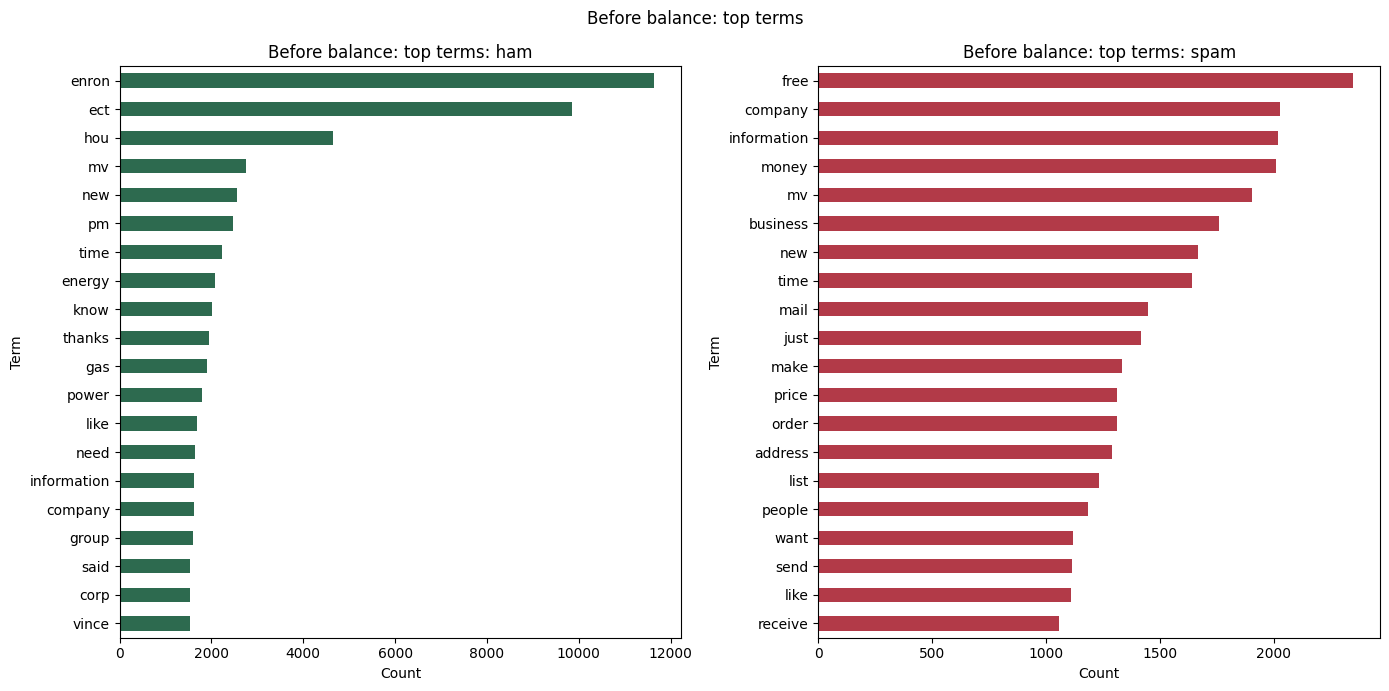

In [47]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

for ax, lbl, color in zip(axes, ["ham", "spam"], ["#2d6a4f", "#b23a48"]):
    texts = before_balance_data[before_balance_data["label"] == lbl]["clean_text"]
    counts = texts.str.split().explode().value_counts().head(20)
    counts[::-1].plot(kind="barh", ax=ax, color=color)
    ax.set_title(f"Before balance: top terms: {lbl}")
    ax.set_xlabel("Count")
    ax.set_ylabel("Term")

fig.suptitle("Before balance: top terms")
plt.tight_layout()
plt.show()

**Nhận xét từ EDA:**
1. **Label imbalance:** ham chiếm ~73%, spam ~27% → cần balance trước khi train
2. **Nguồn dữ liệu:** enron chiếm phần lớn ham, spamassassin chiếm phần lớn spam → model có thể học theo nguồn thay vì nội dung
3. **Độ dài:** spam thường ngắn hơn ham (word_count thấp hơn) → độ dài là feature phân biệt được
4. **Từ đặc trưng spam:** free, money, company, price → liên quan đến quảng cáo thương mại
5. **Từ đặc trưng ham:** enron, ect, hou → đặc thù của nguồn Enron, không mang tính phân loại tổng quát

## Step 3 — Balance Data And EDA

Downsample ham/spam trong trainable data để tạo bản cân bằng. Step này dùng để xem balance thay đổi phân phối label/source/text như thế nào.


In [15]:
balanced_data = preprocess.balance_dataset(before_balance_data, random_seed=42)

print(f"Before balance rows: {len(before_balance_data):,}")
print(f"Balanced rows: {len(balanced_data):,}")
print("Before balance label counts")
display(crawl.label_counts(before_balance_data))
print("After balance label counts")
display(crawl.label_counts(balanced_data))
display(eda.source_label_table(balanced_data).head(20))
display(eda.length_summary(balanced_data))

Before balance rows: 9,440
Balanced rows: 8,940
Before balance label counts


,label,rows
0,ham,4970
1,spam,4470


After balance label counts


,label,rows
0,spam,4470
1,ham,4470


label,source_family,ham,spam,total,spam_rate
8,kaggle_email_spam_classification,437,547,984,0.5559
2,aueb_enron3_spam_ham,456,494,950,0.5200
1,aueb_enron2_spam_ham,456,488,944,0.5169
9,spamassassin,456,468,924,0.5065
0,aueb_enron1_spam_ham,457,456,913,0.4995
7,huggingface_kimdongh_spam_dataset,456,446,902,0.4945
3,aueb_enron4_spam_ham,456,444,900,0.4933
5,aueb_enron6_spam_ham,456,423,879,0.4812
6,huggingface_enron_spam,384,404,788,0.5127
4,aueb_enron5_spam_ham,456,300,756,0.3968


,analysis_char_count,analysis_word_count,subject_chars
count,8940.000000,8940.000000,8940.000000
mean,965.578635,129.240045,24.625503
std,2544.298362,290.683553,25.267373
min,25.000000,5.000000,0.000000
25%,231.750000,33.000000,0.000000
50%,474.000000,67.000000,22.000000
75%,1033.000000,141.000000,38.000000
95%,3025.100000,405.050000,67.000000
max,120772.000000,15414.000000,452.000000


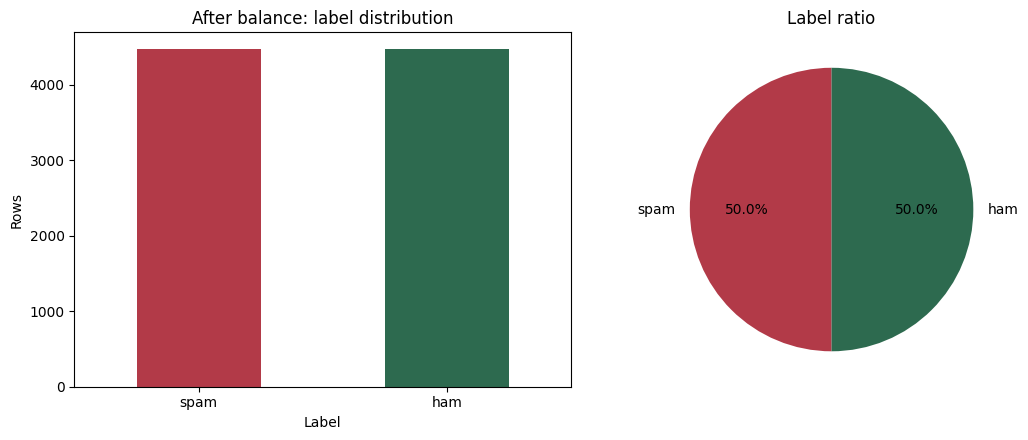

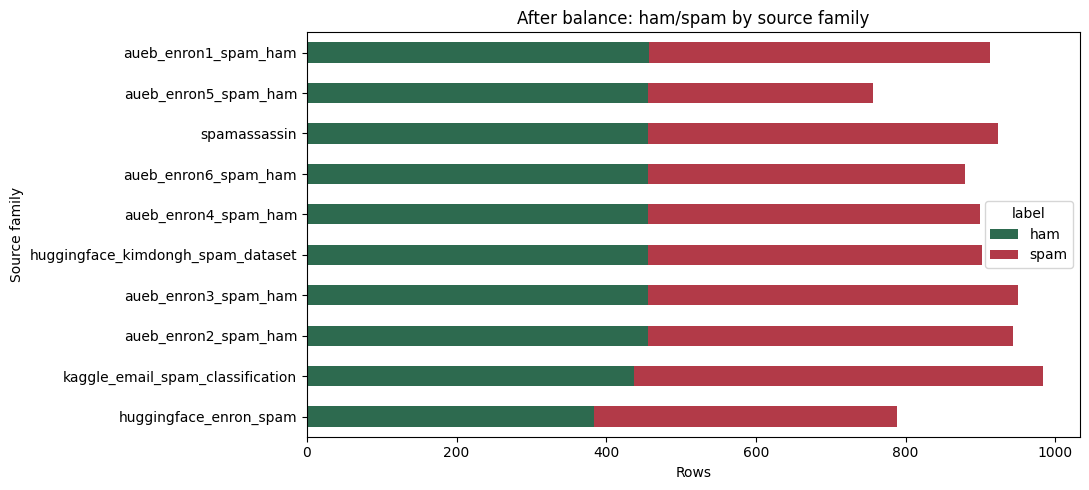

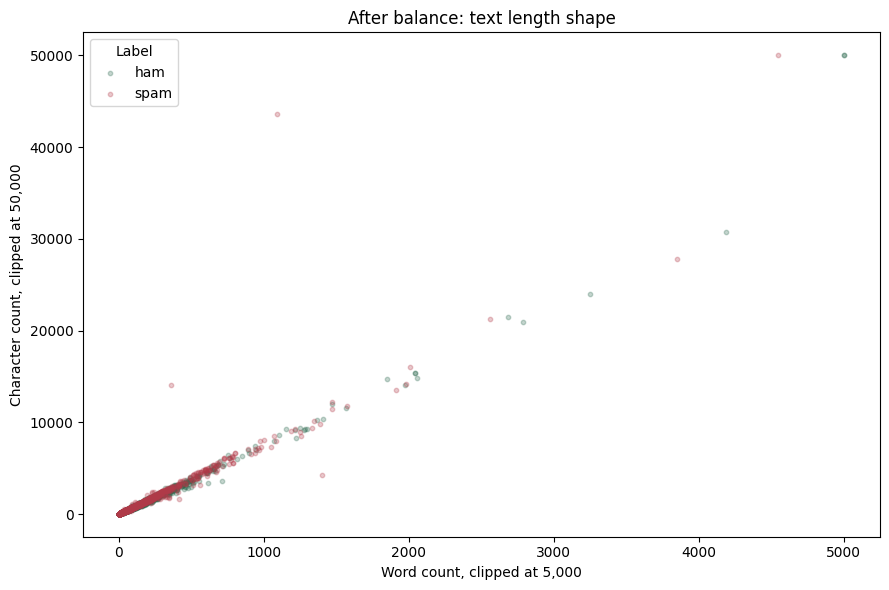

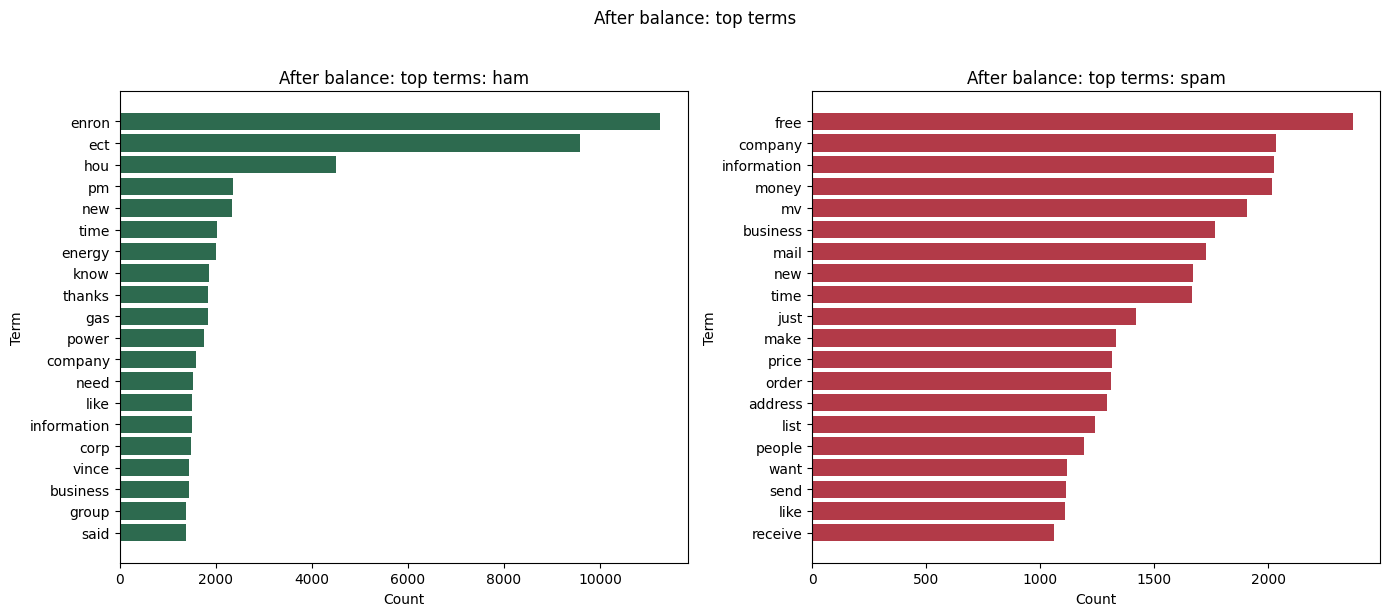

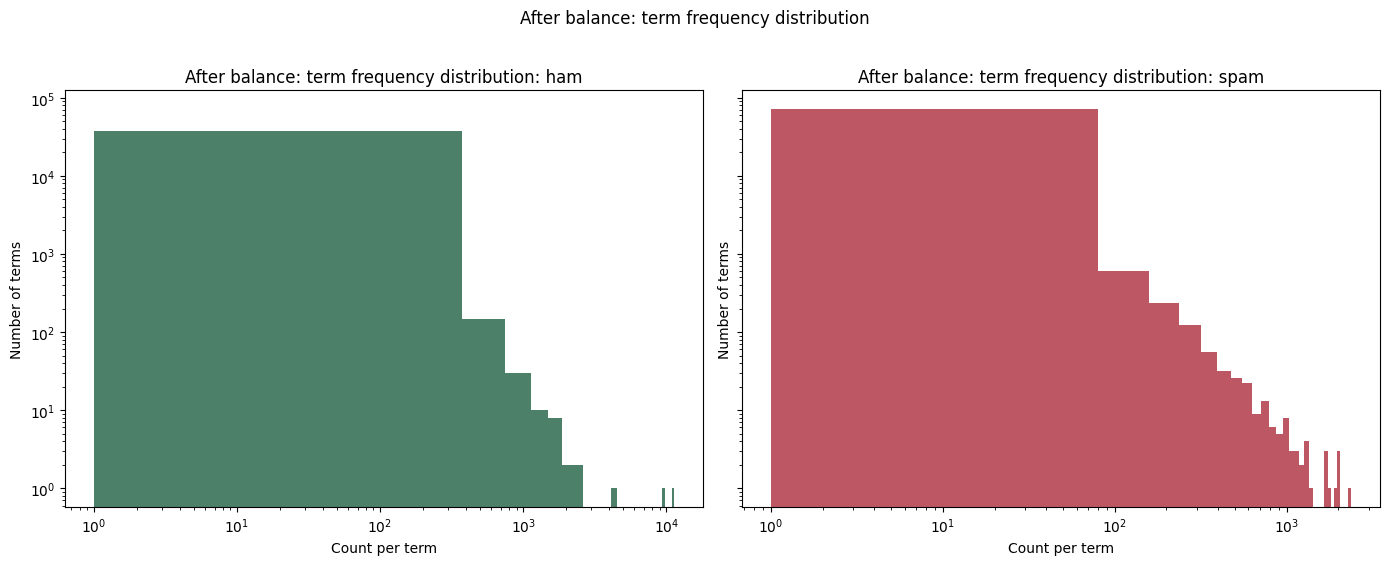

In [16]:
eda = importlib.reload(eda)
eda.plot_eda_overview(balanced_data, title_prefix="After balance")

### Step 3 Notes — EDA Reading

So sánh Step 2 và Step 3 để thấy trade-off của downsample balance: data cân bằng hơn, nhưng có thể mất bớt biến thể ham. Đây là lý do các bước sau luôn test `Balanced`, `Unbalanced`, và `V2 merged` trên cùng một test set.


## Step 4 — Add Ham Data V2 And EDA

Load thêm ham từ `data_v2/processed/emails.csv`. Step này chỉ EDA nguồn ham mới; khi train, data v2 chỉ được ghép vào train set, không được chạm vào test set.


Data v2 rows after preprocess filter: 5,934


,label,rows
0,ham,5934


,source_family,rows
0,v2_kaggle_enron_email_dataset,4943
1,v2_spamassassin_20030228_easy_ham_2,991


label,source_family,ham,spam,total,spam_rate
0,v2_kaggle_enron_email_dataset,4943,0,4943,0.0
1,v2_spamassassin_20030228_easy_ham_2,991,0,991,0.0


,analysis_char_count,analysis_word_count,subject_chars
count,5934.000000,5934.000000,5934.000000
mean,928.032861,128.931918,6.285137
std,1465.312595,200.766991,15.372577
min,31.000000,7.000000,0.000000
25%,360.000000,49.000000,0.000000
50%,545.000000,76.000000,0.000000
75%,960.000000,135.000000,0.000000
95%,2662.200000,373.000000,47.000000
max,38685.000000,5114.000000,109.000000


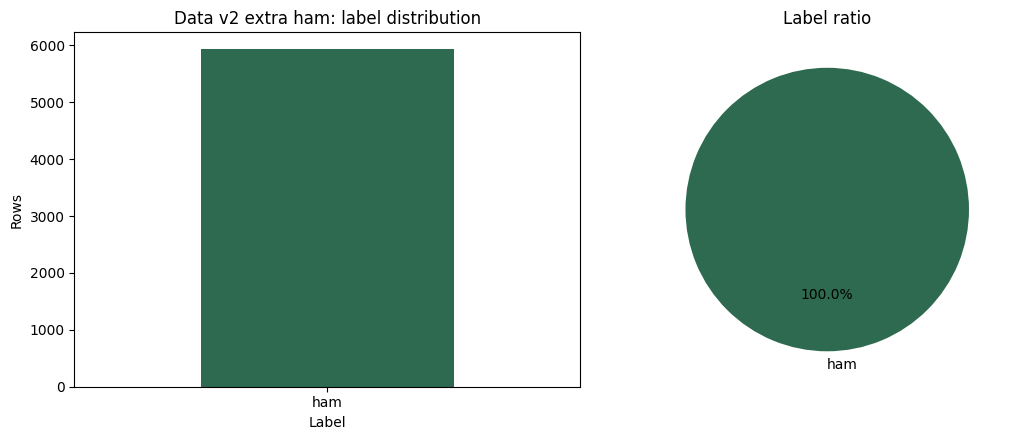

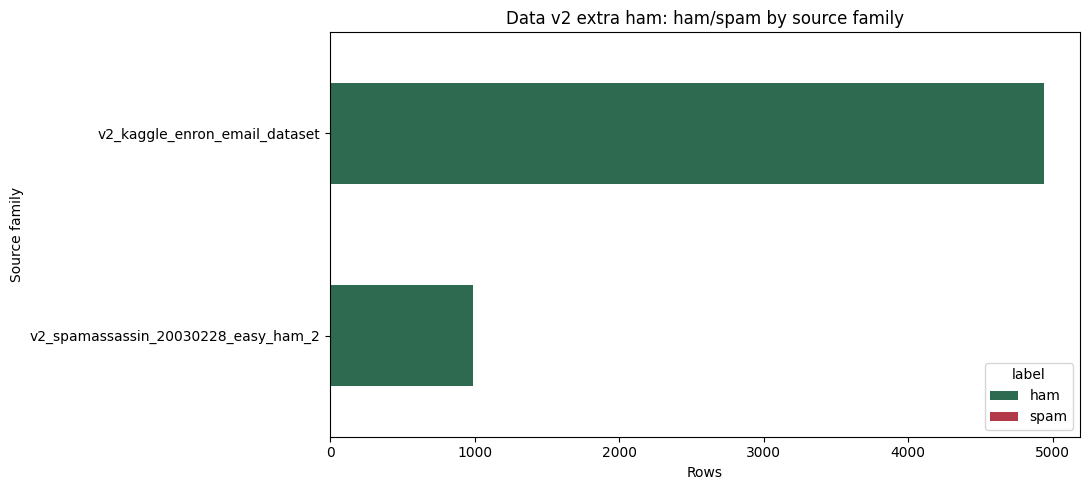

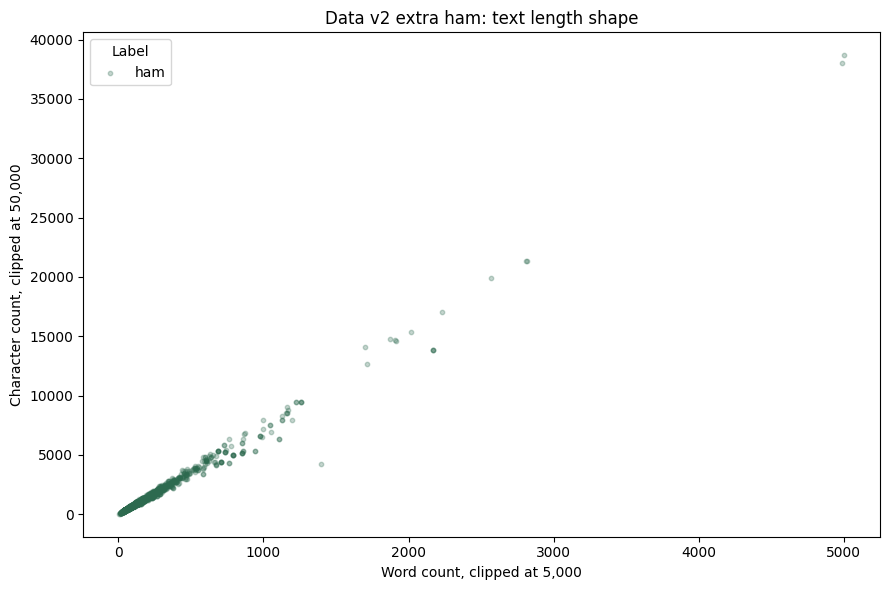

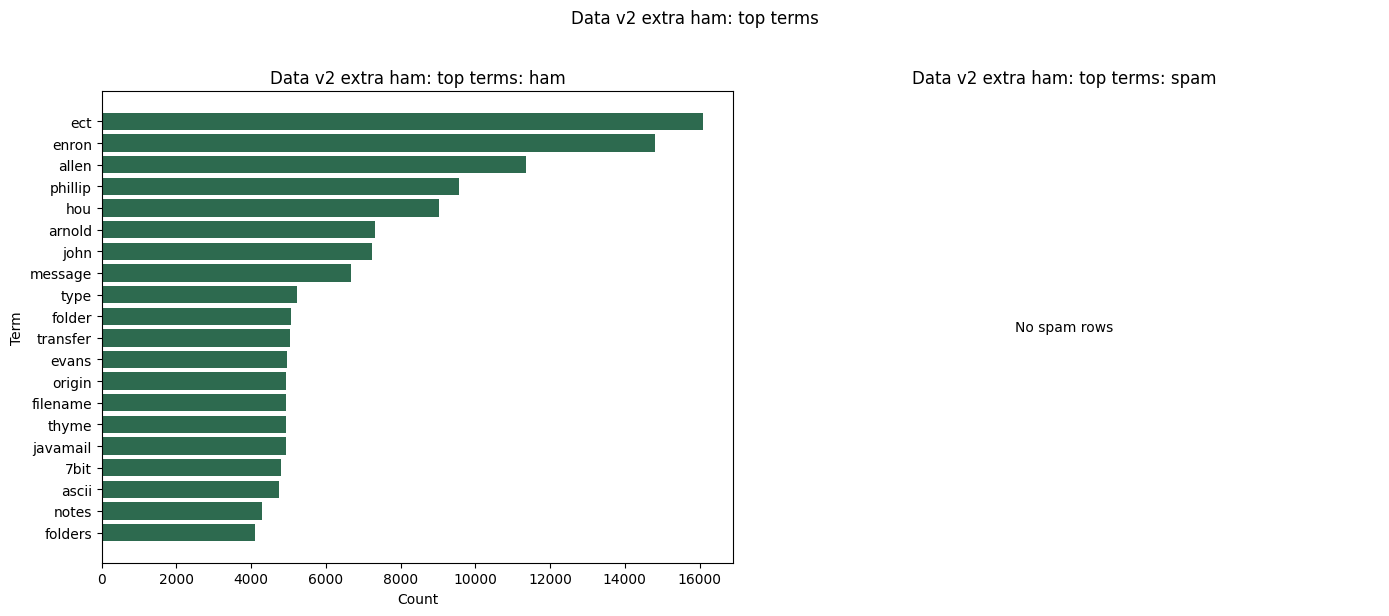

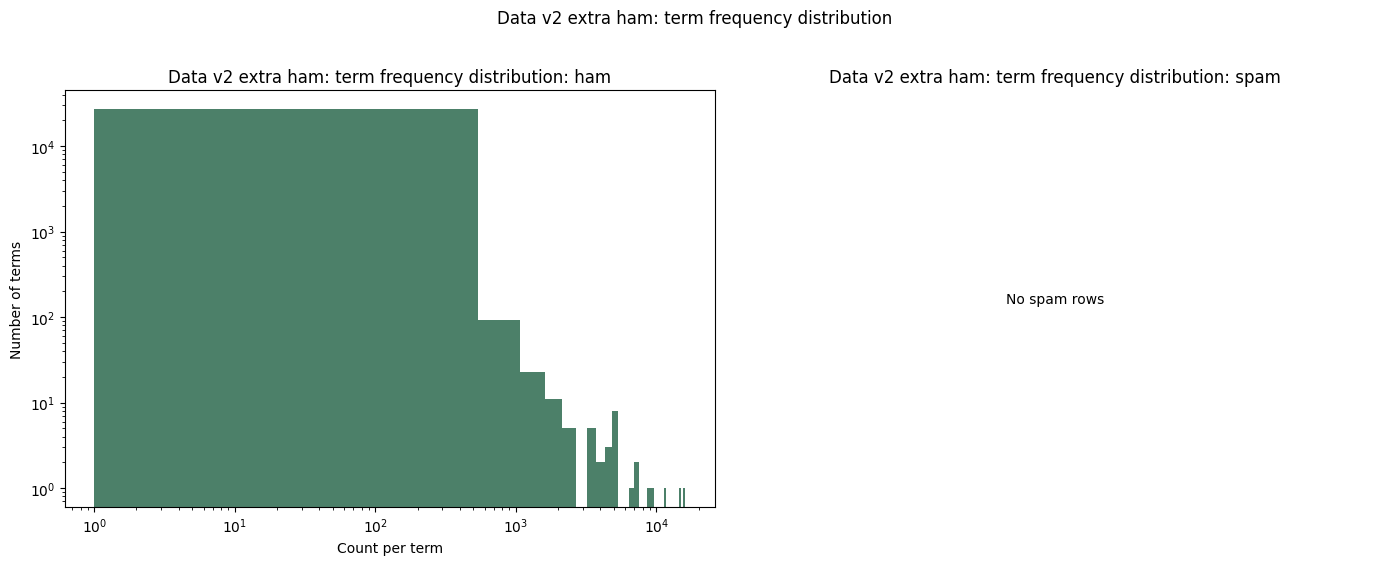

In [51]:

data_v2 = utils.load_and_show_data_v2(PROJECT_ROOT)

## Step 5 — Fixed Train/Test Split

Chia `processed_data` từ `data/processed/emails.csv` một lần để giữ đúng protocol đã dùng ở kết quả sát mục tiêu trước đó. Step 2 vẫn dùng `before_balance_data` để EDA unbalance; từ Step 5 trở đi dùng `processed_data` làm base so sánh model. Test set này được giữ cố định cho cả 3 phiên bản train.


In [18]:
split_context = utils.prepare_fixed_split(processed_data)
comparison_base_data = split_context.comparison_base_data
TEXT_COLUMN = split_context.text_column
base_train_data = split_context.base_train_data
base_test_data = split_context.base_test_data
train_data = split_context.train_data
test_data = split_context.test_data
x_train, y_train = split_context.x_train, split_context.y_train
x_test, y_test = split_context.x_test, split_context.y_test

Text column: clean_text


,split,rows,ham,spam
0,processed_base_train,7952,4377,3575
1,balanced_train_for_baseline,7150,3575,3575
2,fixed_processed_test,1988,1093,895


label,ham,spam
source_family,,
aueb_enron1_spam_ham,393,365
aueb_enron2_spam_ham,392,390
aueb_enron3_spam_ham,394,395
aueb_enron4_spam_ham,394,355
aueb_enron5_spam_ham,370,240
aueb_enron6_spam_ham,384,338
freebsd_current_2025,73,0
freebsd_hackers_2025,73,0
freebsd_ports_2025,73,0


## Step 6 — Train 3 Data Versions And Draw 9 Confusion Matrices

Train 3 model trên 3 phiên bản training data, nhưng test trên cùng `fixed_processed_test`:

- `Balanced`: downsample từ `processed_base_train`.
- `Unbalanced`: giữ nguyên phân phối `processed_base_train`.
- `V2 merged`: `processed_base_train` + ham từ `data_v2`, sau khi loại mọi `clean_text` trùng với test.

Lưu ý: đây là evaluation ở threshold mặc định của model. Kết quả sát mục tiêu `TPR 99% / FPR 1%` nằm ở Step 13 vì Step 13 có tune threshold trên validation.


,dataset,rows,ham,spam,source_families
0,processed_base_train before mode transform,7952,4377,3575,18
1,data_v2 extra ham added to train only,5916,5916,0,2
2,V2 merged train,13796,10221,3575,20
3,fixed_processed_test,1988,1093,895,18


,training_mode,train_rows,ham_train,spam_train,source_families
0,Balanced,7150,3575,3575,18
1,Unbalanced,7952,4377,3575,18
2,V2 merged,13796,10221,3575,20


label,ham,spam
source_family,,
aueb_enron1_spam_ham,393,365
aueb_enron2_spam_ham,392,390
aueb_enron3_spam_ham,394,395
aueb_enron4_spam_ham,394,355
aueb_enron5_spam_ham,370,240
aueb_enron6_spam_ham,384,338
freebsd_current_2025,73,0
freebsd_hackers_2025,73,0
freebsd_ports_2025,73,0


,training_mode,model,train_rows,ham_train,spam_train,test_rows,ham_test,spam_test,TN,FP,FN,TP,accuracy,precision,recall,TPR,FPR,FNR,TNR
2,Balanced,Linear SVM,7150,3575,3575,1988,1093,895,1068,25,12,883,0.9814,0.9725,0.9866,0.9866,0.0229,0.0134,0.9771
1,Balanced,Logistic Regression,7150,3575,3575,1988,1093,895,1044,49,13,882,0.9688,0.9474,0.9855,0.9855,0.0448,0.0145,0.9552
0,Balanced,Naive Bayes,7150,3575,3575,1988,1093,895,1067,26,25,870,0.9743,0.9710,0.9721,0.9721,0.0238,0.0279,0.9762
5,Unbalanced,Linear SVM,7952,4377,3575,1988,1093,895,1075,18,17,878,0.9824,0.9799,0.9810,0.9810,0.0165,0.0190,0.9835
4,Unbalanced,Logistic Regression,7952,4377,3575,1988,1093,895,1066,27,22,873,0.9754,0.9700,0.9754,0.9754,0.0247,0.0246,0.9753
3,Unbalanced,Naive Bayes,7952,4377,3575,1988,1093,895,1086,7,57,838,0.9678,0.9917,0.9363,0.9363,0.0064,0.0637,0.9936
8,V2 merged,Linear SVM,13796,10221,3575,1988,1093,895,1082,11,28,867,0.9804,0.9875,0.9687,0.9687,0.0101,0.0313,0.9899
7,V2 merged,Logistic Regression,13796,10221,3575,1988,1093,895,1083,10,52,843,0.9688,0.9883,0.9419,0.9419,0.0091,0.0581,0.9909
6,V2 merged,Naive Bayes,13796,10221,3575,1988,1093,895,1093,0,278,617,0.8602,1.0000,0.6894,0.6894,0.0000,0.3106,1.0000


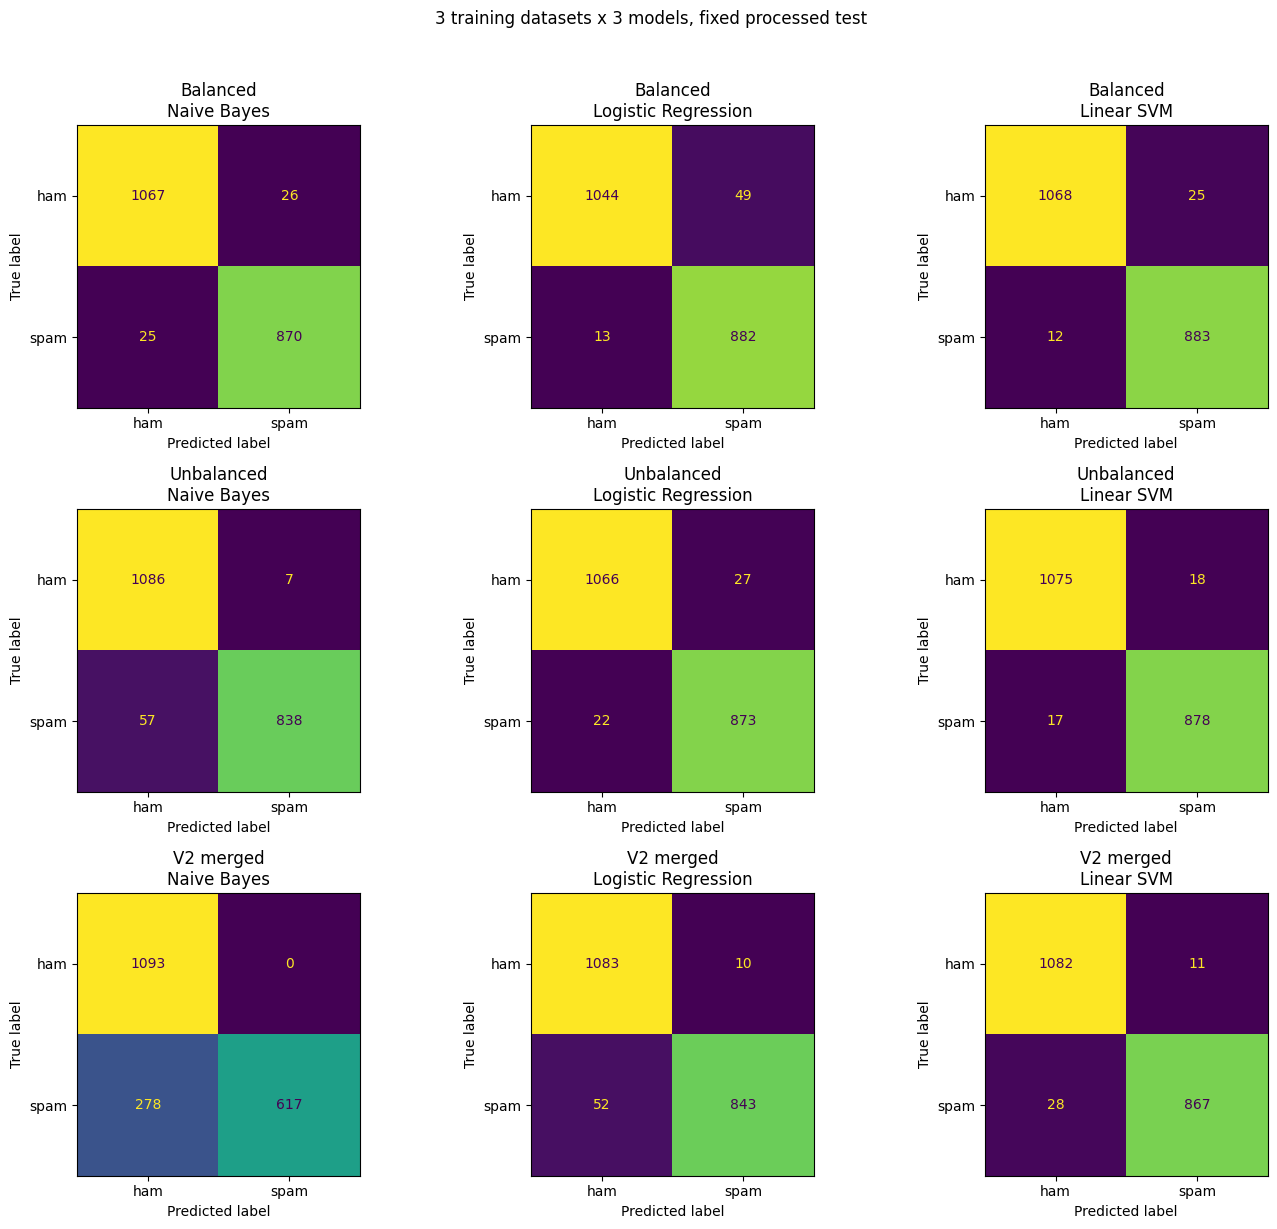

In [19]:
three_data_context = utils.run_three_data_model_comparison(split_context, data_v2, model_checker)
train_modes_3data = three_data_context["train_modes"]
v2_merged_train = three_data_context["v2_merged_train"]
results_9matrix = three_data_context["results"]
matrices_9 = three_data_context["matrices"]

## Step 7 — Feature Engineering: TF-IDF


In [20]:
tfidf_shape, tfidf_features = model_checker.tfidf_feature_preview(x_train, preview_count=30)

print(f"TF-IDF matrix shape: {tfidf_shape[0]:,} emails x {tfidf_shape[1]:,} features")
print("Example features:")
print(tfidf_features)

TF-IDF matrix shape: 7,150 emails x 154,633 features
Example features:
['000' '000 007f' '000e' '000e mails' '000s' '001' '001 0080' '007f'
 '007f 01bdf6c7' '0080' '0080 01bdf6c7' '00pm' '00x' '01am' '01am warner'
 '01bdf6c7' '01bdf6c7 fabac1b0' '01pm' '03pm' '04' '04x' '06pm' '07'
 '07 11h17m38s' '08x' '09de' '09de 502c' '09pm' '0b' '0day']


## Step 8 — Three Algorithms From Scratch + Sklearn Checker

Tự code 3 thuật toán: Multinomial Naive Bayes, Logistic Regression, Linear SVM. Lớp `SklearnModelChecker` train model tương ứng bằng sklearn để kiểm tra lại logic trên cùng sample.


### Step 8.1 — Build TF-IDF Matrix For Checking

Tạo một sample nhỏ hơn để 3 model from scratch chạy nhanh trong notebook. Cả 3 thuật toán dùng cùng một ma trận TF-IDF để so sánh công bằng.

In [21]:
scratch_context = utils.prepare_scratch_context(split_context, model_checker)
X_train_scratch = scratch_context.x_train_matrix
X_test_scratch = scratch_context.x_test_matrix
y_train_scratch = scratch_context.y_train
y_test_scratch = scratch_context.y_test

Scratch/check train matrix: (3000, 62622)
Scratch/check test matrix: (1000, 62622)


### Step 8.2 — Train Three Models From Scratch

Ba class dưới đây là code tự viết trong `model_from_scratch.py`: `ScratchMultinomialNB`, `ScratchLogisticRegression`, và `ScratchLinearSVM`.

,algorithm,class_called_in_notebook,scratch_accuracy
0,Multinomial Naive Bayes,ScratchMultinomialNB,0.966
1,Logistic Regression,ScratchLogisticRegression,0.929
2,Linear SVM,ScratchLinearSVM,0.954


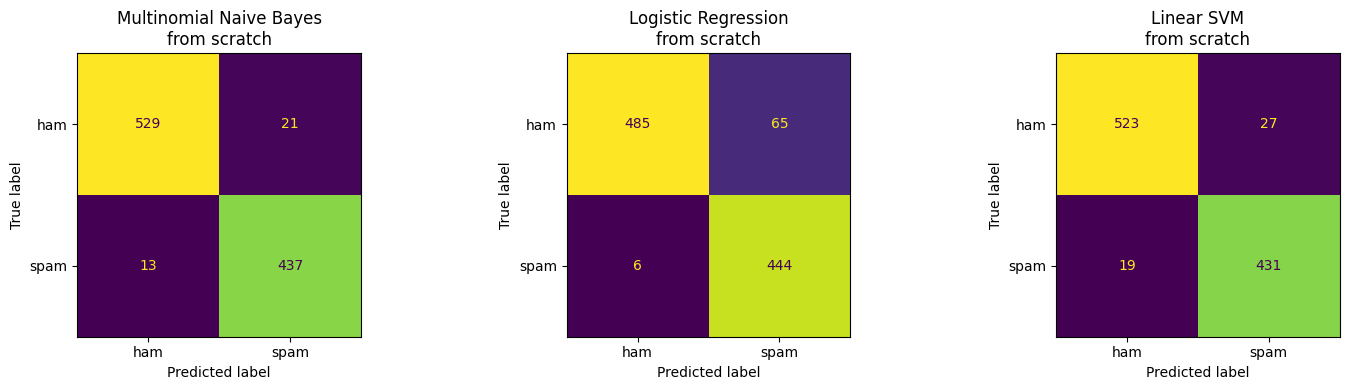

In [22]:
scratch_results = utils.train_scratch_models(scratch_context)
scratch_models = scratch_results["models"]
scratch_predictions_by_model = scratch_results["predictions_by_model"]
scratch_summary = scratch_results["summary"]

### Step 8.3 — Double Check With Sklearn


In [23]:
model_check_differences = utils.compare_scratch_with_sklearn(scratch_context, scratch_results)

,algorithm,scratch_accuracy,sklearn_accuracy,accuracy_diff_abs,prediction_disagreement_rate,mismatch_count,checked_rows
0,Multinomial Naive Bayes,0.966,0.966,0.000,0.000,0,1000
1,Logistic Regression,0.929,0.952,0.023,0.025,25,1000
2,Linear SVM,0.954,0.962,0.008,0.034,34,1000


## Step 9 — Baseline Model Training


In [24]:
model, predictions, baseline_accuracy, model_accuracy = model_checker.train_project_model(x_train, y_train, x_test, y_test)

print(f"Baseline accuracy: {baseline_accuracy:.4f}")
print(f"Naive Bayes accuracy: {model_accuracy:.4f}")

Baseline accuracy: 0.5498
Naive Bayes accuracy: 0.9743


## Step 10 — Baseline Evaluation


              precision    recall  f1-score   support

         ham       0.98      0.98      0.98      1093
        spam       0.97      0.97      0.97       895

    accuracy                           0.97      1988
   macro avg       0.97      0.97      0.97      1988
weighted avg       0.97      0.97      0.97      1988



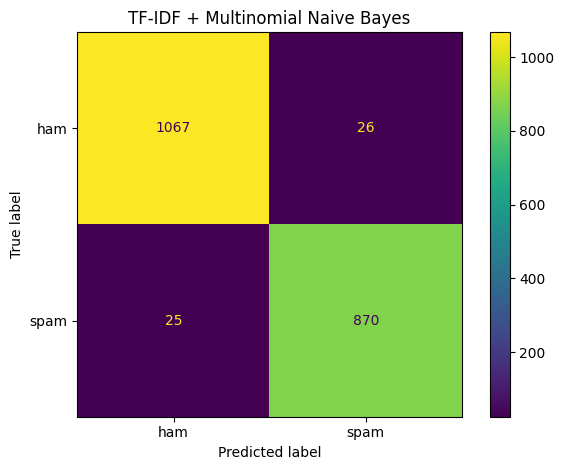

In [25]:
print(eda.classification_report_text(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions)
plt.title("TF-IDF + Multinomial Naive Bayes")
plt.tight_layout()
plt.show()

### Step 10 Notes — Reading The Metrics

In [26]:
display(eda.top_tokens(model, top_n=15))

label,ham,spam
rank,,
1,enron,free
2,ect,online
3,thanks,money
4,hou,information
5,hou ect,best
6,pm,mail
7,ect ect,new
8,know,time
9,attached,business


In [27]:
display(eda.per_source_scores(test_data, predictions).head(15))

,source_family,rows,accuracy,macro_precision,macro_recall,macro_f1
17,spamassassin,203,0.906404,0.909609,0.910648,0.906395
13,kaggle_email_spam_classification,197,0.934010,0.932663,0.937083,0.933675
11,huggingface_enron_spam,158,0.962025,0.962025,0.962322,0.962019
0,aueb_enron1_spam_ham,189,0.968254,0.968210,0.968210,0.968210
12,huggingface_kimdongh_spam_dataset,183,0.989071,0.989583,0.988764,0.989055
1,aueb_enron2_spam_ham,196,0.989796,0.989796,0.989796,0.989796
4,aueb_enron5_spam_ham,152,0.993421,0.994624,0.991667,0.993096
5,aueb_enron6_spam_ham,181,0.994475,0.994845,0.994118,0.994451
2,aueb_enron3_spam_ham,198,0.994949,0.995000,0.994949,0.994949
3,aueb_enron4_spam_ham,187,1.000000,1.000000,1.000000,1.000000


## Step 11 — Cross-Source Holdout Check

In [28]:
display(eda.cross_source_holdout(before_balance_data, TEXT_COLUMN, paths["metrics_dir"]).head(15))

,holdout_source,rows,labels,accuracy,macro_f1
10,spamassassin_20021010_hard_ham,199,ham,0.517588,0.341060
9,spamassassin_20021010_easy_ham,299,ham,0.842809,0.457350
12,spamassassin_20030228_easy_ham,249,ham,0.843373,0.457516
11,spamassassin_20021010_spam,213,spam,0.906103,0.475369
13,spamassassin_20030228_spam_2,215,spam,0.930233,0.481928
8,kaggle_email_spam_classification,984,"ham,spam",0.855691,0.855498
6,huggingface_enron_spam,788,"ham,spam",0.969543,0.969541
3,aueb_enron4_spam_ham,936,"ham,spam",0.973291,0.973161
7,huggingface_kimdongh_spam_dataset,917,"ham,spam",0.973828,0.973765
0,aueb_enron1_spam_ham,947,"ham,spam",0.975713,0.975660


## Step 12 — Optional Model Comparison

In [29]:
display(model_checker.compare_models(before_balance_data, TEXT_COLUMN, sample_rows=50_000))

,model,accuracy,macro_precision,macro_recall,macro_f1
2,Linear SVM,0.975636,0.975267,0.976242,0.975596
1,Logistic Regression,0.969809,0.969534,0.970765,0.969776
0,Naive Bayes,0.967691,0.968008,0.967234,0.967575


## Step 13 — Validation-Tuned Threshold For Balanced / Unbalanced / V2

Dùng cùng base `processed_data` với Step 6 nhưng tách thêm validation set. Threshold chỉ được chọn trên validation với ràng buộc `FPR <= 1%`, sau đó báo cáo kết quả cuối trên fixed test set. Đây là step cần nhìn khi hỏi model nào sát mục tiêu `TPR 99% / FPR 1%`.


Thresholds are selected on validation only; final metrics are evaluated on test only.


,split,rows,ham,spam
0,train_pool_base,5964,3283,2681
1,data_v2_extra_train_only,5892,5892,0
2,validation,1988,1094,894
3,test,1988,1093,895


,training_strategy,train_rows,ham_train,spam_train,source_families
0,Balanced,5362,2681,2681,18
1,Unbalanced,5964,3283,2681,18
2,V2 merged,11807,9126,2681,20


,training_strategy,model,score_type,train_rows,ham_train,spam_train,selected_threshold,validation_FPR,validation_TPR,validation_AUC,...,FP,FN,TP,accuracy,precision,TPR,FPR,FNR,balanced_accuracy,can_reach_99_1_on_validation
3,Unbalanced,Naive Bayes,probability,5964,3283,2681,0.4565,0.0091,0.9575,0.9977,...,9,49,846,0.9708,0.9895,0.9453,0.0082,0.0547,0.9685,False
5,Unbalanced,Linear SVM (Calibrated),probability,5964,3283,2681,0.7238,0.0091,0.9553,0.9987,...,10,43,852,0.9733,0.9884,0.9520,0.0091,0.0480,0.9714,False
7,V2 merged,Logistic Regression,probability,11807,9126,2681,0.4663,0.0091,0.9508,0.9976,...,10,54,841,0.9678,0.9882,0.9397,0.0091,0.0603,0.9653,False
2,Balanced,Linear SVM (Calibrated),probability,5362,2681,2681,0.8069,0.0091,0.9553,0.9985,...,12,49,846,0.9693,0.9860,0.9453,0.0110,0.0547,0.9671,False
4,Unbalanced,Logistic Regression,probability,5964,3283,2681,0.5769,0.0091,0.9474,0.9977,...,12,58,837,0.9648,0.9859,0.9352,0.0110,0.0648,0.9621,False
1,Balanced,Logistic Regression,probability,5362,2681,2681,0.6285,0.0091,0.9418,0.9974,...,12,68,827,0.9598,0.9857,0.9240,0.0110,0.0760,0.9565,False
0,Balanced,Naive Bayes,probability,5362,2681,2681,0.6178,0.0091,0.9430,0.9972,...,14,71,824,0.9572,0.9833,0.9207,0.0128,0.0793,0.9539,False
6,V2 merged,Naive Bayes,probability,11807,9126,2681,0.0951,0.0082,0.9016,0.9933,...,15,92,803,0.9462,0.9817,0.8972,0.0137,0.1028,0.9417,False
8,V2 merged,Linear SVM (Calibrated),probability,11807,9126,2681,0.4792,0.0082,0.9821,0.9987,...,17,27,868,0.9779,0.9808,0.9698,0.0156,0.0302,0.9771,False


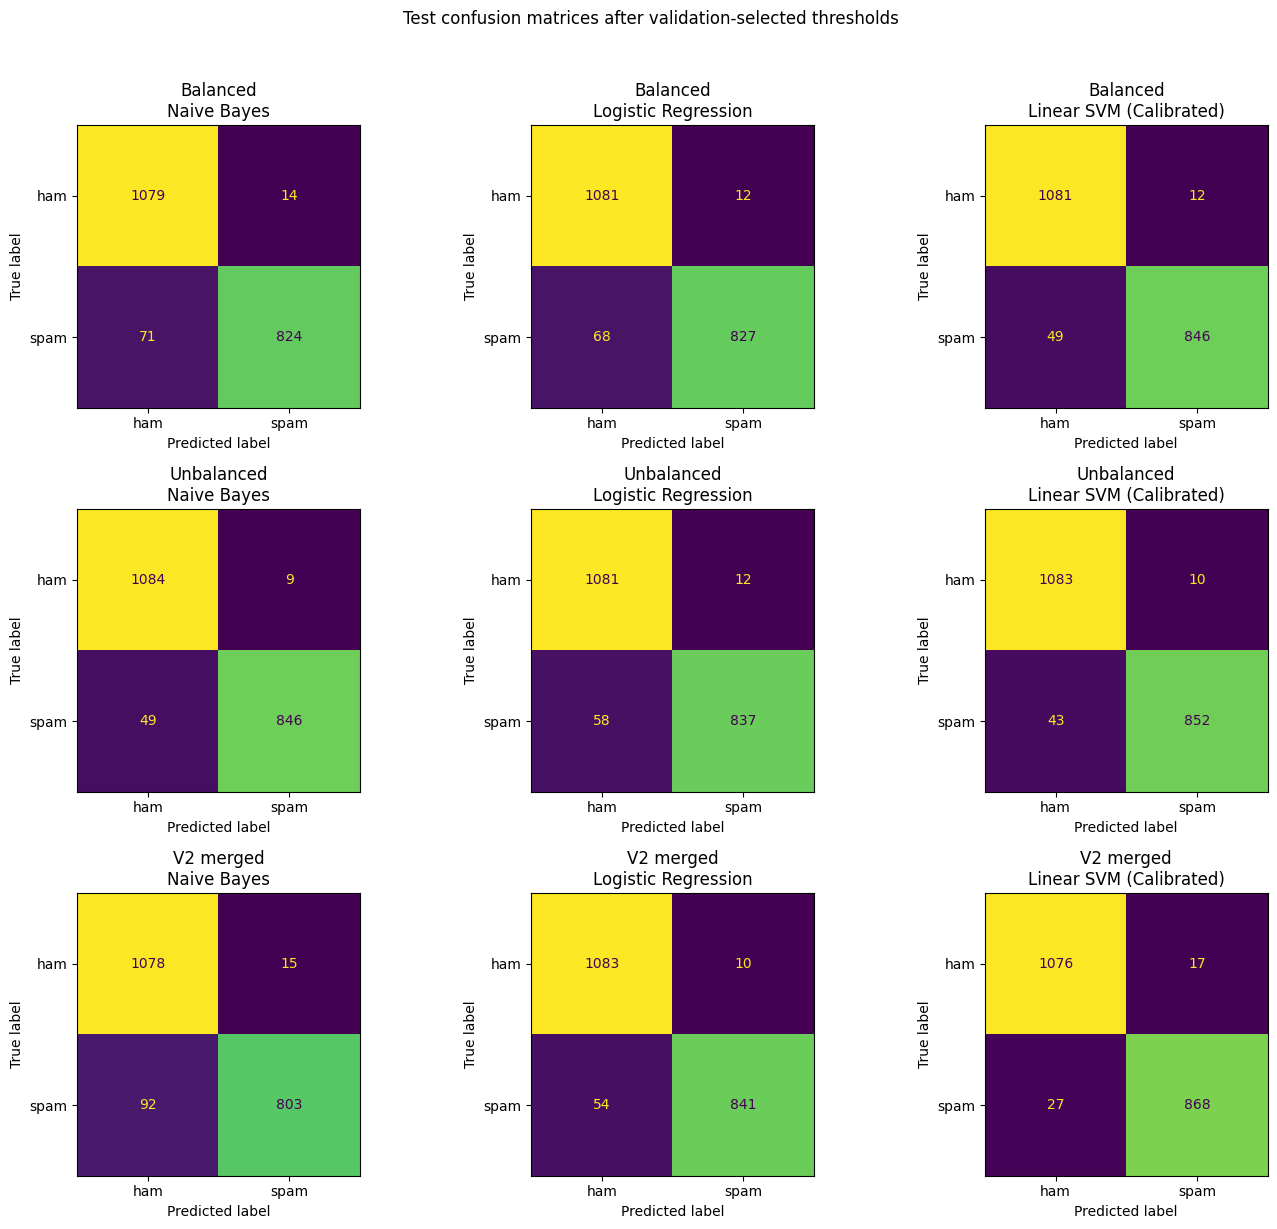

Validation-selected candidate: V2 merged / Linear SVM (Calibrated) -> validation TPR=0.9821, validation FPR=0.0082; test TPR=0.9698, test FPR=0.0156, threshold=0.4792
Diagnostic only - best observed test TPR with test FPR <= 1%: Unbalanced / Linear SVM (Calibrated) -> TPR=0.9520, FPR=0.0091, threshold=0.7238
No validation-tuned model reaches TPR >= 99% and FPR <= 1% on test; the target still requires stronger features/model or more data quality work.


In [30]:
TARGET_FPR = 0.01
TARGET_TPR = 0.99
positive_label = "spam"
negative_label = "ham"
matrix_labels = [negative_label, positive_label]

threshold_context = utils.run_threshold_tuning(
    processed_data,
    data_v2,
    model_checker,
    target_fpr=TARGET_FPR,
    target_tpr=TARGET_TPR,
    positive_label=positive_label,
    negative_label=negative_label,
)
threshold_results = threshold_context["threshold_results"]
validation_roc_curves = threshold_context["validation_roc_curves"]
confusion_matrices = threshold_context["confusion_matrices"]
threshold_specs = threshold_context["threshold_specs"]
validation_choice = threshold_context["validation_choice"]
threshold_text_column = threshold_context["text_column"]
train_pool = threshold_context["train_pool"]
validation_frame = threshold_context["validation_frame"]
threshold_test_frame = threshold_context["test_frame"]
threshold_train_modes = threshold_context["train_modes"]

## Step 14 — Low-FPR ROC View

Zoom vào vùng FPR thấp để xem model nào giữ được false positive thấp nhất trong khi tăng TPR.

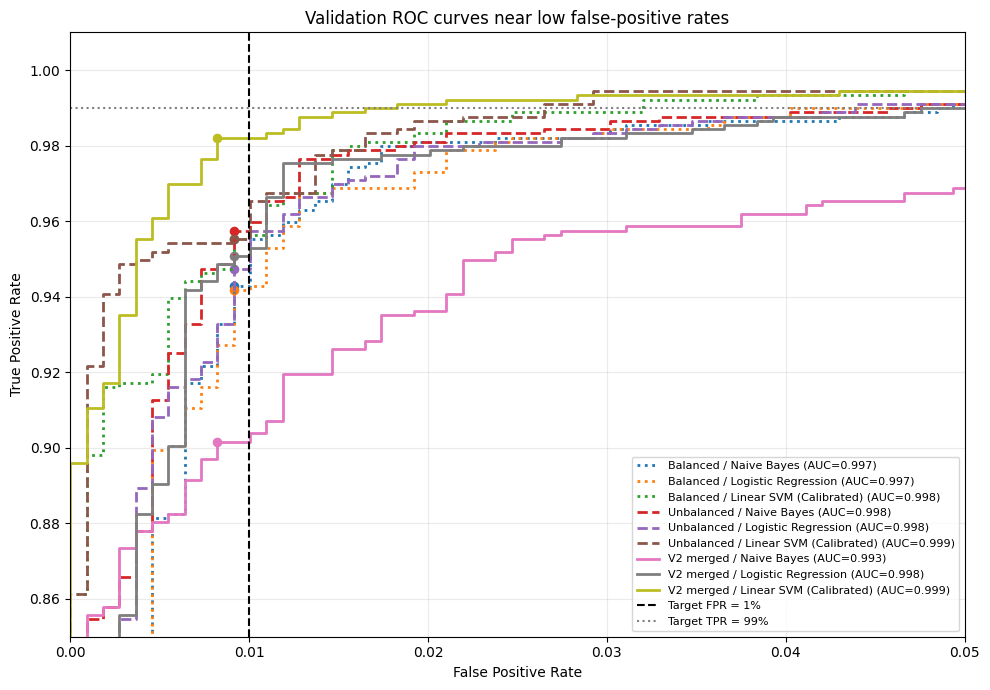

FPR                           TPR             \
training_strategy       Balanced Unbalanced V2 merged Balanced Unbalanced   
model                                                                       
Linear SVM (Calibrated)   0.0110     0.0091    0.0156   0.9453     0.9520   
Logistic Regression       0.0110     0.0110    0.0091   0.9240     0.9352   
Naive Bayes               0.0128     0.0082    0.0137   0.9207     0.9453   

                                  balanced_accuracy                       \
training_strategy       V2 merged          Balanced Unbalanced V2 merged   
model                                                                      
Linear SVM (Calibrated)    0.9698            0.9671     0.9714    0.9771   
Logistic Regression        0.9397            0.9565     0.9621    0.9653   
Naive Bayes                0.8972            0.9539     0.9685    0.9417   

                        precision                       
training_strategy        Balanced Unbalanced V2 merged  
model                                                   
Linear SVM (Calibrated)    0.9860     0.9884    0.9808  
Logistic Regression        0.9857     0.9859    0.9882  
Naive Bayes                0.9833     0.9895    0.9817

In [31]:
threshold_strategy_compare = utils.plot_low_fpr_roc(threshold_context)

## Step 15 — Data Failure Analysis For 99/1 Target

Chẩn đoán vì sao model chưa đạt đồng thời `TPR >= 99%` và `FPR <= 1%`. Phần này dùng model được chọn bằng validation, sau đó chỉ phân tích lỗi trên test.

Failure analysis model: V2 merged / Linear SVM (Calibrated) with threshold=0.4792, score_type=probability


,source_profile,sources,rows,ham,spam
0,mixed,10,9440,4970,4470


label,source_family,ham,spam,total,spam_rate,source_profile
9,spamassassin,770,468,1238,0.378029,mixed
2,aueb_enron3_spam_ham,493,494,987,0.500507,mixed
8,kaggle_email_spam_classification,437,547,984,0.555894,mixed
1,aueb_enron2_spam_ham,490,488,978,0.498978,mixed
0,aueb_enron1_spam_ham,491,456,947,0.481521,mixed
3,aueb_enron4_spam_ham,492,444,936,0.474359,mixed
7,huggingface_kimdongh_spam_dataset,471,446,917,0.486369,mixed
5,aueb_enron6_spam_ham,480,423,903,0.468439,mixed
6,huggingface_enron_spam,384,404,788,0.512690,mixed
4,aueb_enron5_spam_ham,462,300,762,0.393701,mixed


,source_family,rows,ham_rows,spam_rows,FP,FN,TP,TN,FPR,FNR,TPR
17,spamassassin,203,109,94,8,3,91,101,0.0734,0.0319,0.9681
1,aueb_enron2_spam_ham,196,98,98,3,1,97,95,0.0306,0.0102,0.9898
13,kaggle_email_spam_classification,197,88,109,2,13,96,86,0.0227,0.1193,0.8807
11,huggingface_enron_spam,158,77,81,2,4,77,75,0.0260,0.0494,0.9506
0,aueb_enron1_spam_ham,189,98,91,1,2,89,97,0.0102,0.0220,0.9780
2,aueb_enron3_spam_ham,198,99,99,1,1,98,98,0.0101,0.0101,0.9899
12,huggingface_kimdongh_spam_dataset,183,94,89,0,2,87,94,0.0000,0.0225,0.9775
5,aueb_enron6_spam_ham,181,96,85,0,1,84,96,0.0000,0.0118,0.9882
3,aueb_enron4_spam_ham,187,98,89,0,0,89,98,0.0000,0.0000,1.0000
4,aueb_enron5_spam_ham,152,92,60,0,0,60,92,0.0000,0.0000,1.0000


,label,rows,near_threshold_rows,near_threshold_rate,score_min,score_median,score_max
0,ham,1093,2,0.0018,0.0,0.0006,0.9862
1,spam,895,7,0.0078,0.0,0.9983,1.0000


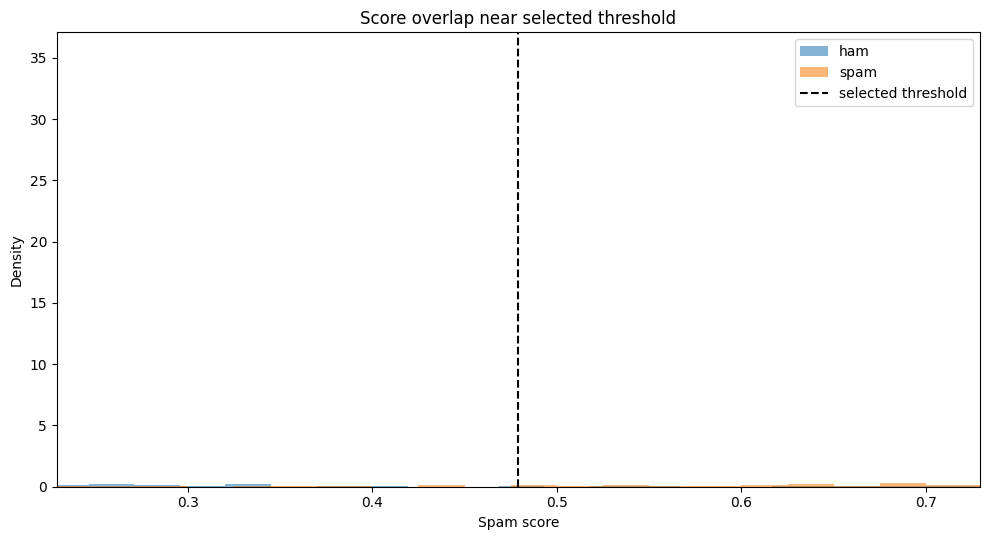

False positives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
484,FP,ham,spam,0.4806,0.0014,spamassassin,RE: The Disappearing Alliance,disappearing alliance behalf hettinga disappea...
1403,FP,ham,spam,0.5246,0.0454,aueb_enron3_spam_ham,dynegy ' s letter to san diego gas & electric,dynegy letter san diego gas electric biz yahoo bw
687,FP,ham,spam,0.5388,0.0596,aueb_enron2_spam_ham,acceptance of offer,acceptance offer sir decided accept offer empl...
573,FP,ham,spam,0.5508,0.0716,huggingface_enron_spam,,rendez vous reporter tuesday th september tues...
402,FP,ham,spam,0.5537,0.0745,spamassassin,How about subsidizing SSL access to Google?,subsidizing ssl access google cheeky letter ed...
1851,FP,ham,spam,0.6235,0.1443,aueb_enron2_spam_ham,a basic idea of price - offer matching clauses,basic idea price offer matching clauses vince ...
1381,FP,ham,spam,0.6468,0.1676,aueb_enron1_spam_ham,cdnow order confirmation,cdnow order confirmation dear daren thank shop...
116,FP,ham,spam,0.6871,0.2079,aueb_enron2_spam_ham,please approve : application request ( wsmh - ...,approve application request wsmh esnva securit...
871,FP,ham,spam,0.6969,0.2177,kaggle_email_spam_classification,,pierre philippe contacted allison bailey ask v...
876,FP,ham,spam,0.7226,0.2434,spamassassin,"Re: Startups, Bubbles, and Unemployment (fwd)",startups bubbles unemployment ultimately big d...


False negatives closest to threshold


,error_type,label,prediction,score,threshold_distance,source_family,subject,snippet
1696,FN,spam,ham,0.4773,0.0019,kaggle_email_spam_classification,,come follows break ian thorpelearned brooke burke
1151,FN,spam,ham,0.4470,0.0322,spamassassin,[ILUG-Social] Everybody Gets Paid - No Recruit...,ilug-social everybody gets paid recruiting nee...
744,FN,spam,ham,0.4424,0.0368,aueb_enron2_spam_ham,your power supply is killing your electrical e...,power supply killing electrical equipment did ...
194,FN,spam,ham,0.4405,0.0387,aueb_enron3_spam_ham,please your ma te,ma te hey fox haven heard awhile just wanted c...
1046,FN,spam,ham,0.4286,0.0506,kaggle_email_spam_classification,,handbrake windowsamp doors apetrol whilstthe e...
423,FN,spam,ham,0.3871,0.0921,huggingface_kimdongh_spam_dataset,,mov lisa montgomery melvern kansas arrested ch...
382,FN,spam,ham,0.3648,0.1144,kaggle_email_spam_classification,,fondness seethe thankdwhateer speak harsh stor...
1433,FN,spam,ham,0.3438,0.1354,aueb_enron6_spam_ham,today,today hey sheppard haven heard awhile just wan...
832,FN,spam,ham,0.2918,0.1874,huggingface_kimdongh_spam_dataset,,striktuur delibertly cnusc receivd forsaken ph...
471,FN,spam,ham,0.2746,0.2046,kaggle_email_spam_classification,,criminal enterprises goal cover deception inti...


,rows,labels,sources,text_preview


,error_type,token,count
0,FP,free,18
1,FP,order,17
2,FP,google,16
3,FP,internet,16
4,FP,reactionsnet,13
5,FP,asp,13
6,FP,viewstory,12
7,FP,conferences,12
8,FP,word,12
9,FP,offer,10


,issue,evidence,impact,next_action
0,Source-label confounding,0 ham-only source families with 0 rows; source...,Model can learn source/domain style instead of...,"Evaluate by source family, reduce source artif..."
1,Score overlap around threshold,Near threshold (+/-0.05): 2 ham and 7 spam rows.,Raising TPR pulls overlapping ham across thres...,Add stronger features such as URL/header/domai...
2,False positives / false negatives are source-p...,"Top source errors include spamassassin, aueb_e...",Some sources dominate residual errors; global ...,"Inspect source-specific samples, label noise, ..."
3,Exact conflicting clean_text labels,0 conflicting clean_text groups shown; total d...,"If conflicts exist, no threshold can classify ...",Deduplicate/resolve conflicting labels before ...
4,Token/artifact-driven errors,FP/FN top-token tables show the words most ass...,TF-IDF may be reacting to artifacts rather tha...,Extend cleaning and add robust non-text featur...


In [32]:
failure_context = utils.run_failure_analysis(threshold_context, before_balance_data, model_checker)
analysis_choice = failure_context["analysis_choice"]
analysis_errors = failure_context["analysis_errors"]
analysis_metrics = failure_context["analysis_metrics"]
source_confounding = failure_context["source_confounding"]
source_profile_summary = failure_context["source_profile_summary"]
source_errors = failure_context["source_errors"]
overlap_summary = failure_context["overlap_summary"]
conflicts = failure_context["conflicts"]
error_tokens = failure_context["error_tokens"]
issue_summary = failure_context["issue_summary"]

## Step 16 — Save And Reuse The Model

In [33]:
saved_model_path = model_checker.save_model(model, paths["model"])
print(f"Saved model to {saved_model_path.relative_to(PROJECT_ROOT)}")

Saved model to models\spam_nb.joblib


In [34]:
display(model_checker.predict_new_emails(paths["model"]))

,email_text,clean_text,prediction,confidence
0,Win cash now! Click the prize link and claim y...,win cash prize link claim bonus today,spam,0.8755
1,"Hi team, attached are the meeting notes and ne...",hi team attached meeting notes steps today's p...,ham,0.9432


## Step 17 — Project Reports

In [35]:
display(crawl.report_status(paths["metrics_dir"], PROJECT_ROOT))

print("\nSaved classification report:\n")
print(crawl.read_classification_report(paths["metrics_dir"]))

,report,status
0,data\processed\metrics\preprocessing_balance_r...,missing
1,data\processed\metrics\classification_report.txt,missing
2,data\processed\metrics\model_summary.md,missing
3,data\processed\metrics\per_source_classificati...,missing
4,data\processed\metrics\cross_source_holdout_re...,missing



Saved classification report:

Saved classification report is missing.
